# Customer Segmentation using K-Means Clustering

### Minor Project

**Name:** Shaurabh Pandey

**Technology Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn

**Algorithm**
- K-Means Clustering

**Objective**

The objective of this project is to segment customers into different groups based on their purchasing behavior using the K-Means clustering algorithm. This helps businesses understand customer patterns and improve marketing strategies.



In [17]:
# Import Required Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Display Settings
pd.set_option("display.max_columns", None)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


## Data Loading

In this step, we load the dataset into a Pandas DataFrame for further analysis.

In [2]:
import os

print(os.getcwd())

c:\Users\shaur\Desktop\Customer-Segmentation-ML\notebook


In [3]:
import os

print(os.listdir("../dataset"))

['Mall_Customers.csv']


In [4]:
import os

print(os.path.abspath("../dataset/Mall_Customers.csv"))
print(os.path.exists("../dataset/Mall_Customers.csv"))


c:\Users\shaur\Desktop\Customer-Segmentation-ML\dataset\Mall_Customers.csv
True


In [5]:
from pathlib import Path
import pandas as pd

dataset_path = Path.cwd().parent / "dataset" / "Mall_Customers.csv"

print(dataset_path)
print(dataset_path.exists())

df = pd.read_csv(dataset_path)
df.head()

c:\Users\shaur\Desktop\Customer-Segmentation-ML\dataset\Mall_Customers.csv
True


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Dataset Overview

Before building the clustering model, it is important to understand the dataset. This section provides information about the structure, data types, missing values, and statistical summary of the dataset.

In [6]:
print("Rows and Columns :", df.shape)

Rows and Columns : (200, 5)


In [7]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [8]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Genre                   200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
# Missing Values

df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [11]:
# Duplicate Values

df.duplicated().sum()

np.int64(0)

In [12]:
# Check Data Types

df.dtypes

CustomerID                int64
Genre                       str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution of data, relationships between variables, and patterns before applying the clustering algorithm.

In [13]:
# Display first 10 records

df.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [14]:
df.tail(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
190,191,Female,34,103,23
191,192,Female,32,103,69
192,193,Male,33,113,8
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [15]:
df.sample(5)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
10,11,Male,67,19,14
29,30,Female,23,29,87
103,104,Male,26,62,55
125,126,Female,31,70,77
61,62,Male,19,46,55


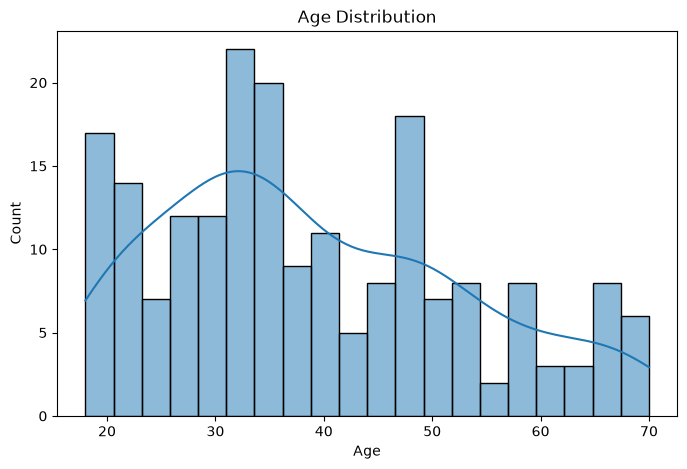

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.savefig("../images/age_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

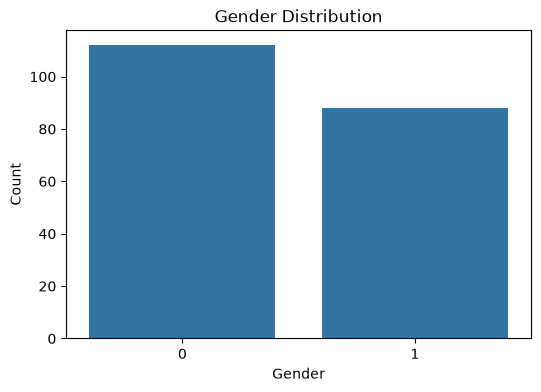

In [47]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("../images/gender_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

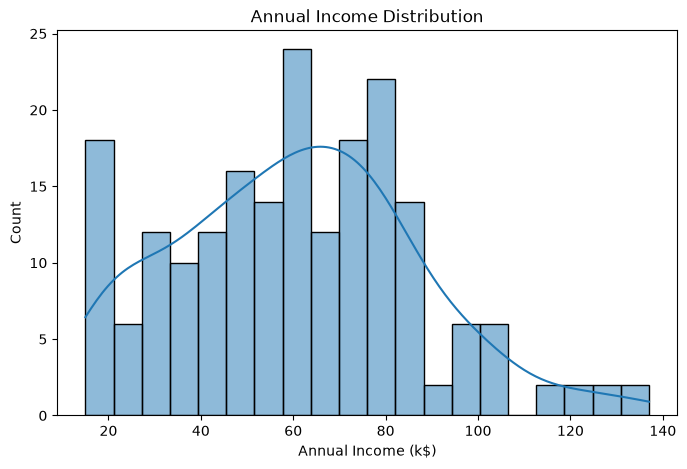

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.savefig("../images/income_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

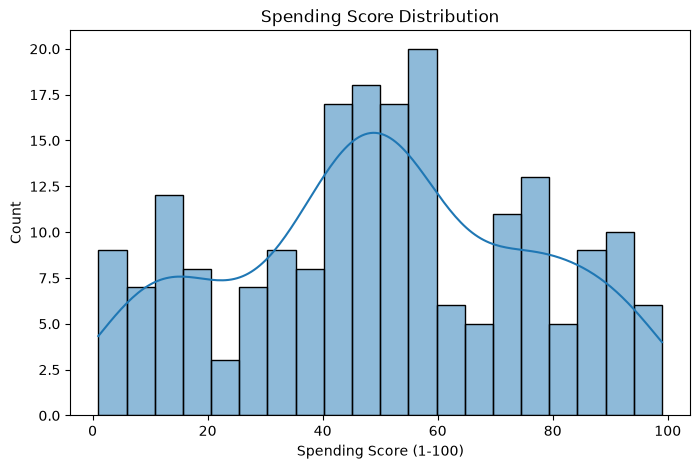

In [49]:
plt.figure(figsize=(8,5))

sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.savefig("../images/spending_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

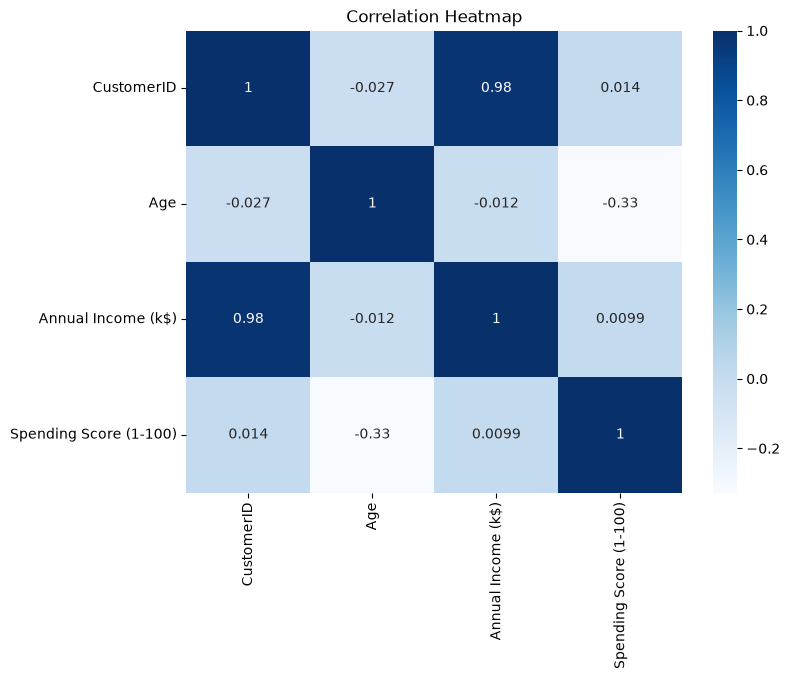

In [27]:
plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

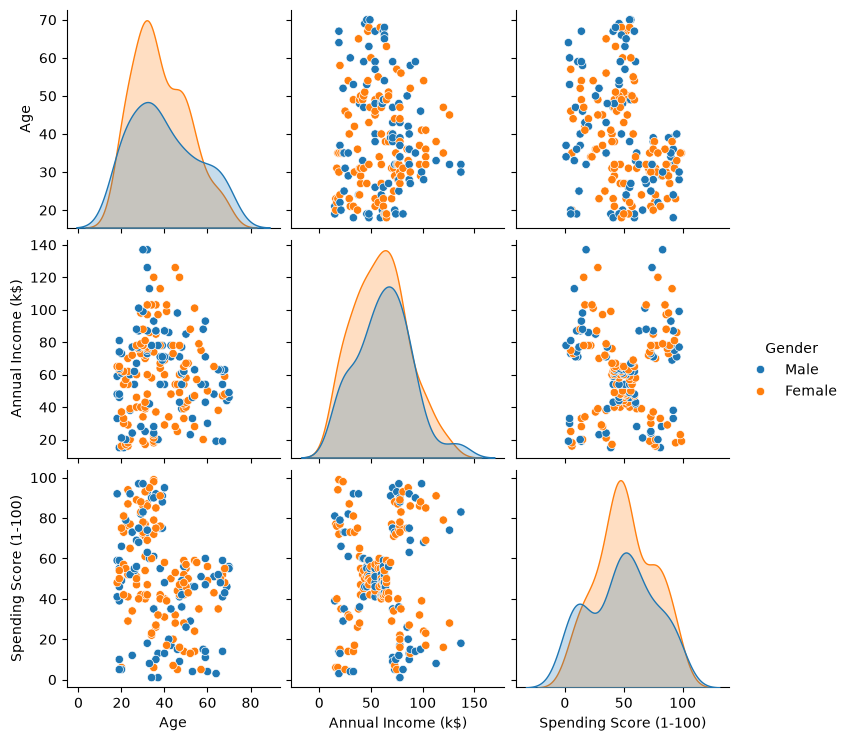

In [28]:
sns.pairplot(df.drop(columns=["CustomerID"]),
             hue="Gender")

plt.show()

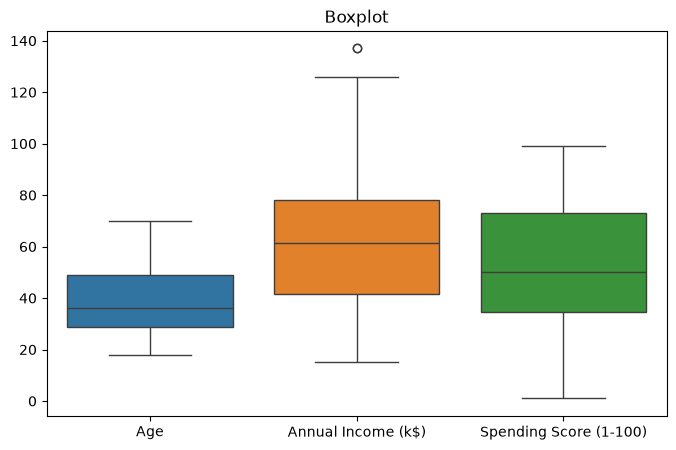

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df[["Age","Annual Income (k$)","Spending Score (1-100)"]])

plt.title("Boxplot")

plt.show()

# Data Preprocessing

Before applying the K-Means clustering algorithm, we preprocess the dataset by:

- Removing unnecessary columns
- Encoding categorical variables
- Feature Scaling

In [30]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [31]:
df = df.drop("CustomerID", axis=1)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [32]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_data

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [35]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


# Finding the Optimal Number of Clusters (Elbow Method)

The Elbow Method helps determine the optimal number of clusters (K) by plotting the Within Cluster Sum of Squares (WCSS). The point where the curve bends like an elbow is considered the optimal value of K.

In [36]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

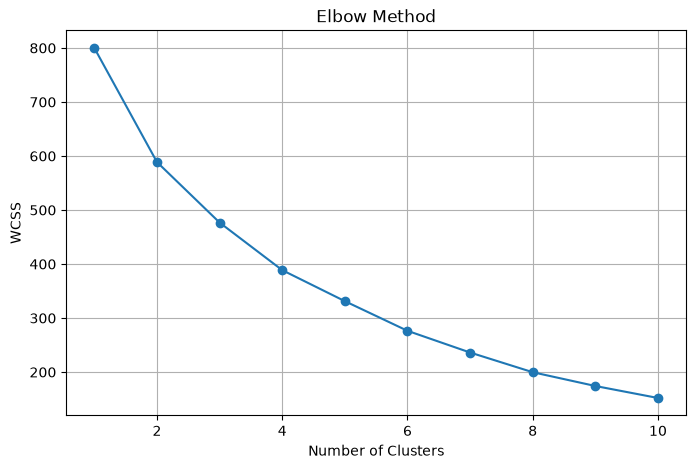

In [50]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.grid(True)
plt.savefig("../images/elbow_method.png", dpi=300, bbox_inches="tight")

plt.show()

From the Elbow graph, the bend appears around **K = 5**. Therefore, we choose **5 clusters** for customer segmentation.

# Training the K-Means Model

Using the optimal number of clusters (K = 5), we train the K-Means clustering model.

In [39]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

clusters

array([3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 2, 3, 4, 3, 2, 3, 4, 3, 3, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 4, 3, 4, 3, 2, 3, 2, 3, 2, 3, 2, 3, 4, 3,
       2, 3, 2, 3, 3, 3, 2, 3, 3, 4, 2, 4, 2, 4, 3, 4, 4, 3, 2, 2, 4, 3,
       2, 2, 3, 3, 4, 2, 2, 2, 4, 3, 2, 4, 3, 2, 4, 4, 4, 2, 3, 4, 2, 3,
       3, 2, 2, 3, 4, 2, 2, 3, 2, 3, 4, 3, 3, 2, 4, 3, 4, 3, 2, 4, 4, 4,
       4, 3, 2, 3, 3, 3, 2, 2, 2, 2, 3, 2, 2, 0, 1, 0, 4, 0, 4, 0, 4, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 2, 0, 1, 0, 1, 0, 4, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 2, 0, 1, 0, 4, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       4, 0, 4, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0], dtype=int32)

In [40]:
df["Cluster"] = clusters

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,3
1,1,21,15,81,3
2,0,20,16,6,3
3,0,23,16,77,3
4,0,31,17,40,3


In [41]:
df["Cluster"].value_counts().sort_index()

Cluster
0    39
1    29
2    43
3    54
4    35
Name: count, dtype: int64

# Visualizing Customer Clusters

The following scatter plot shows how customers are grouped based on Annual Income and Spending Score.

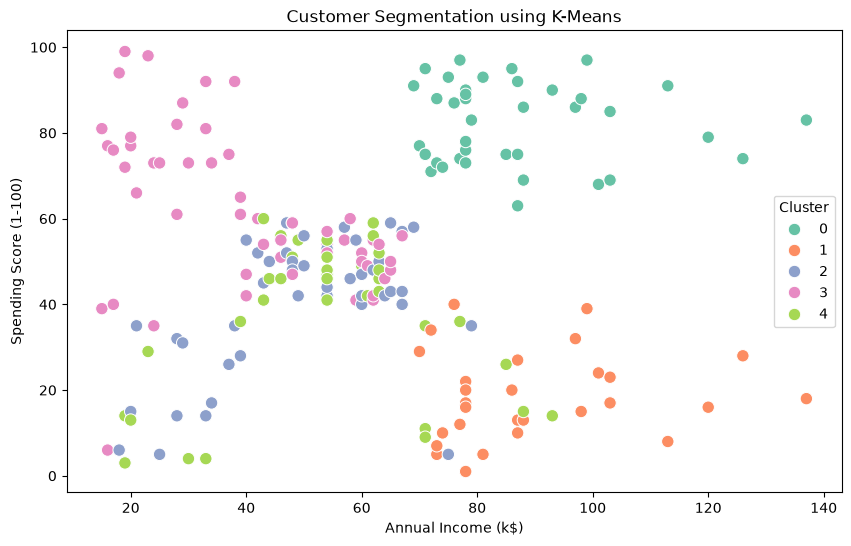

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=80
)


plt.title("Customer Segmentation using K-Means")
plt.savefig("../images/customer_clusters.png", dpi=300, bbox_inches="tight")

plt.show()

# Model Evaluation

The Silhouette Score measures how well-separated the clusters are.

In [43]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df, clusters)

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.304


In [44]:
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.drop(columns=["Cluster"]).columns
)

centers

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,4.615385e-01,32.692308,86.538462,82.128205
1,4.482759e-01,36.482759,89.517241,18.000000
2,-5.551115e-17,49.813953,49.232558,40.069767
3,4.074074e-01,24.907407,39.722222,61.203704
4,1.000000e+00,55.714286,53.685714,36.771429


# Conclusion

In this project, K-Means Clustering was successfully applied to segment customers into five distinct groups based on Age, Gender, Annual Income, and Spending Score.

These customer segments can help businesses:
- Identify high-value customers.
- Design targeted marketing campaigns.
- Improve customer satisfaction.
- Increase overall sales and business growth.

The Silhouette Score indicates that the clustering model has formed reasonably well-separated customer groups.